In [ ]:
import argparse
import torch
from torch import nn
import yaml
import data_set_prep
from models import PitchSalience, PitchSalienceUnet
import utils

In [7]:
model_path = "cqt_0.pth"
config_file = "configs/cqt.yaml"
eval_root = "Data/Evaluation/vocadito"
batch_size = 1
debug = True

device = "cuda" if torch.cuda.is_available() else "cpu"

with open(config_file, "r") as config_file:
    config = yaml.safe_load(config_file)

map_location = None if device == "cuda" else torch.device("cpu")
model = torch.load(model_path, map_location=map_location, weights_only=False)
model = model.to(device)
model.eval()

eval_loader = data_set_prep.get_evaluation_dataloader(
    config,
    dataset_root=eval_root,
    batch_size=batch_size,
    debug=debug,
)

X_batch, y_batch = next(iter(eval_loader))
X_batch = X_batch.to(device)
y_batch = y_batch.to(device)

with torch.no_grad():
    predicted_salience_logits = model(X_batch)
    predicted_salience = torch.sigmoid(predicted_salience_logits)

reshaped = (torch.squeeze(predicted_salience, [0, 3])).numpy()

processing HCQTs and targets:   0%|          | 0/40 [00:04<?, ?it/s]


pred_map shape (freq,time): (216, 50), target_map shape (freq,time): (216, 50)


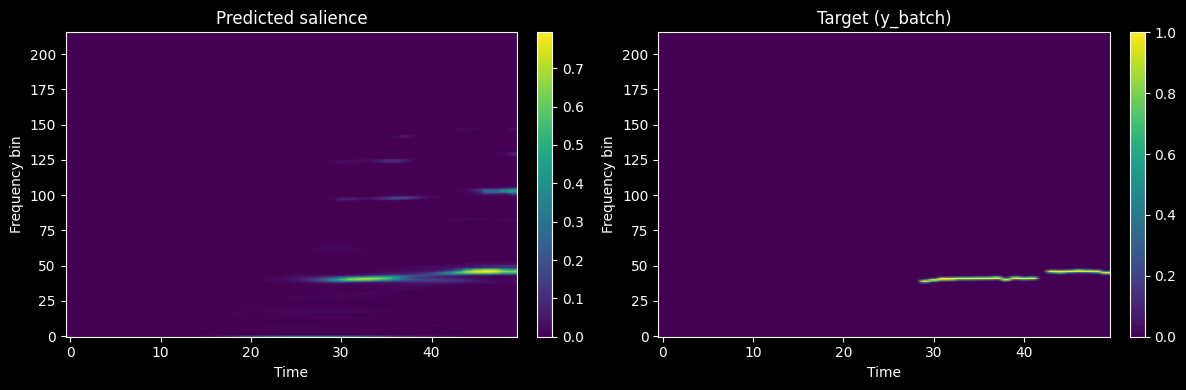

In [ ]:
import matplotlib.pyplot as plt

pred_map = torch.squeeze(predicted_salience[0], 2).detach().cpu().numpy().transpose(1, 0)
target_map = torch.squeeze(y_batch[0], 2).detach().cpu().numpy().transpose(1, 0)

print(f"pred_map shape (freq,time): {pred_map.shape}, target_map shape (freq,time): {target_map.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im0 = axes[0].imshow(pred_map, aspect="auto", origin="lower")
axes[0].set_title("Predicted salience")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(target_map, aspect="auto", origin="lower")
axes[1].set_title("Target (y_batch)")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xlabel("Time")
    ax.set_ylabel("Frequency bin")

plt.tight_layout()
plt.show()
